# Model Training

In [13]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split


Load data

In [14]:
df_matches_with_features = pd.read_csv("model/matches_with_features.csv")

Split features and labels

In [15]:
feature_cols = [
    "total_goals_team1",
    "num_players_with_goals_team1",
    "max_goals_by_single_player_team1",
    "total_matches_team1",
    "matches_with_goals_team1",
    "matches_without_goals_team1",
    "avg_goals_per_match_team1",
    "total_goals_team2",
    "num_players_with_goals_team2",
    "max_goals_by_single_player_team2",
    "total_matches_team2",
    "matches_with_goals_team2",
    "matches_without_goals_team2",
    "avg_goals_per_match_team2",
    "goals_diff",
    "matches_diff",
    "avg_goals_diff",
    "num_players_with_goals_diff",
    "max_goals_diff"
]

X = df_matches_with_features[feature_cols]
y = df_matches_with_features["win"]

Split to training and testing dataset

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Training with simple Random Forest model

In [17]:
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Evaluation

In [18]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": clf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(10))

Accuracy: 0.6623376623376623
              precision    recall  f1-score   support

           0       0.71      0.77      0.74        95
           1       0.57      0.49      0.53        59

    accuracy                           0.66       154
   macro avg       0.64      0.63      0.63       154
weighted avg       0.66      0.66      0.66       154

                         feature  importance
16                avg_goals_diff    0.144227
14                    goals_diff    0.096356
17   num_players_with_goals_diff    0.078270
15                  matches_diff    0.070658
18                max_goals_diff    0.067592
6      avg_goals_per_match_team1    0.055945
13     avg_goals_per_match_team2    0.053387
0              total_goals_team1    0.044577
7              total_goals_team2    0.043193
8   num_players_with_goals_team2    0.040557


Output model, feature columns and metadata

In [19]:
joblib.dump(clf, "model/worldcup_model.pkl")
joblib.dump(feature_cols, "model/feature_columns.pkl")
model_info = {
    "model": "RandomForestClassifier",
    "trained_on": "Worldcup data 2002 - 2022",
    "accuracy": accuracy,
    "features": feature_cols
}

joblib.dump(model_info, "model/model_metadata.pkl")

['model/model_metadata.pkl']

Visualization

/var/folders/xw/cqtpjnb545180n_0bdh4k0500000gn/T/ipykernel_3182/2162521914.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


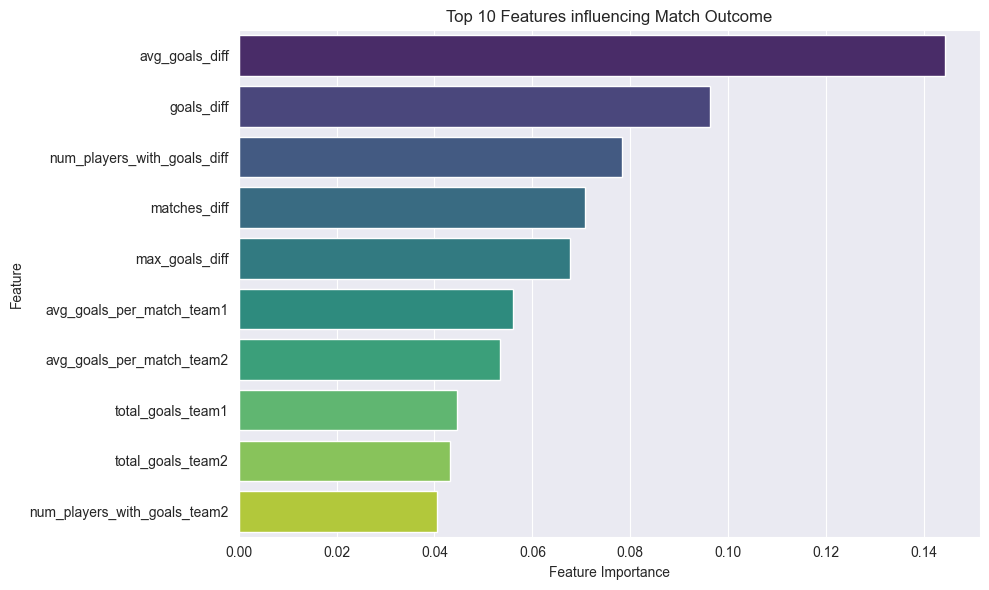

In [20]:
top_features = feat_imp.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x="importance",
    y="feature",
    data=top_features,
    palette="viridis"
)
plt.title("Top 10 Features influencing Match Outcome")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

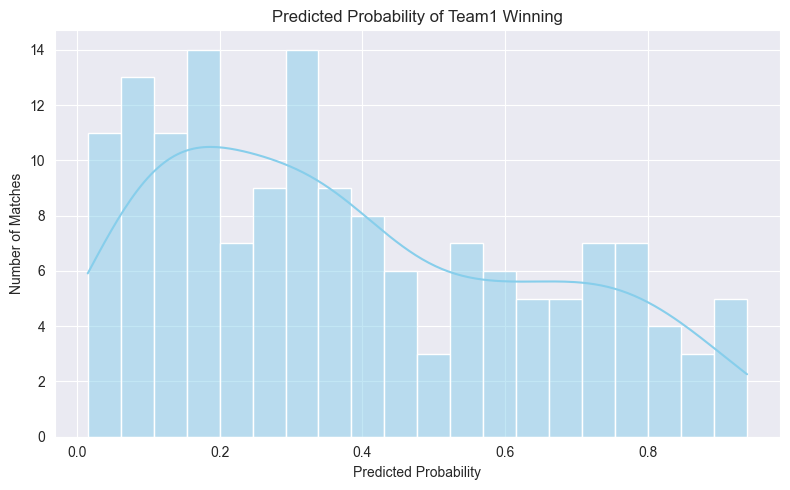

In [21]:
y_prob = clf.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,5))
sns.histplot(y_prob, bins=20, kde=True, color="skyblue")
plt.title("Predicted Probability of Team1 Winning")
plt.xlabel("Predicted Probability")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()